# Notebook 2: Popularity-Based Recommendation System

## Objective

The objective of this notebook is to build a Popularity-Based Recommendation System using the Product Summary Dataset created in Notebook 1.

Unlike personalized recommendation systems, popularity-based recommendations suggest products that have performed well overall, regardless of an individual customer's purchase history.

This approach serves as a strong baseline recommendation model and is particularly useful for new users who have not yet interacted with the platform.

---

## Why are we building a Popularity-Based Recommendation System?

Recommendation systems aim to help customers discover products they are likely to purchase.

The simplest and most widely used baseline approach is popularity-based recommendation, where products are ranked according to their overall popularity within the business.

In our project, product popularity is represented by the **Popularity Score**, which combines:

- Total Quantity Sold
- Total Revenue
- Purchase Frequency

These metrics were calculated and normalized in Notebook 1.

---

## Business Importance

Popularity-based recommendation systems are widely used in e-commerce platforms because they:

- Solve the Cold Start Problem for new users.
- Highlight trending and high-performing products.
- Increase product visibility.
- Improve customer engagement.
- Provide a reliable baseline before implementing personalized recommendation techniques.

Although simple, this method often delivers strong performance when user-specific information is unavailable.

---

## Expected Outcome

By the end of this notebook, we will:

- Load the Product Summary Dataset.
- Build a reusable popularity-based recommendation function.
- Generate Top-N product recommendations.
- Validate the recommendation output.
- Save the recommendation dataset for future notebooks and deployment.

# Section 2: Import Required Libraries

## Objective

The objective of this section is to import all the libraries required for building and evaluating the Popularity-Based Recommendation System.

Only the libraries necessary for data loading, visualization, and file management are imported to keep the notebook clean and efficient.

---

## Why are these libraries required?

Each library serves a specific purpose:

- **Pandas** is used for loading and manipulating the product summary dataset.
- **Matplotlib** is used for visualizing recommendation results.
- **Warnings** suppress unnecessary warning messages for cleaner notebook output.
- **Project configuration paths** provide a centralized way to access project directories without hardcoding file paths.

Using centralized project paths improves maintainability and makes the notebook portable across different environments.

---

## Expected Outcome

By the end of this section, the notebook environment will be configured and all required libraries will be available for the subsequent recommendation pipeline.

In [3]:
# ==========================================
# Project Path Setup
# ==========================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: C:\Users\bhard\Intelligent Customer Analytics Platform


In [4]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

import warnings

from config.paths import DATA_DIR, REPORTS_DIR

warnings.filterwarnings("ignore")

In [5]:
# ==========================================
# Notebook Configuration
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)

plt.style.use("ggplot")

### Observation

All required libraries have been successfully imported, and the notebook environment has been configured. The use of centralized project paths ensures consistent access to project resources while avoiding hardcoded directory locations.

### Section Summary

In this section, we imported the libraries required for loading the product summary dataset, creating visualizations, and managing project paths. The notebook environment is now configured and ready to begin building the Popularity-Based Recommendation System.

# Section 3: Load & Validate Product Summary Dataset

## Objective

The objective of this section is to load the Product Summary Dataset created in Notebook 1 and verify that it contains all the information required for building the Popularity-Based Recommendation System.

Instead of recreating the product summary from the original transaction dataset, we will reuse the saved dataset to maintain a modular and efficient machine learning workflow.

---

## Why are we loading the Product Summary Dataset?

The Product Summary Dataset contains aggregated product-level information such as sales quantity, revenue, purchase frequency, popularity score, and popularity rank.

These features were computed in Notebook 1 and will serve as the primary input for generating popularity-based recommendations.

---

## Business Importance

Reusing processed datasets reduces computation time, improves consistency across notebooks, and reflects how production recommendation systems are typically designed.

It also ensures that all recommendation models use the same validated product information.

---

## Expected Outcome

By the end of this section, we will:

- Locate the Product Summary Dataset.
- Load it into a Pandas DataFrame.
- Verify its structure.
- Confirm that all required columns are available for the recommendation pipeline.

In [6]:
# ==========================================
# Product Summary Dataset Path
# ==========================================

dataset_path = DATA_DIR / "recommendation" / "product_summary.csv"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
C:\Users\bhard\Intelligent Customer Analytics Platform\data\recommendation\product_summary.csv


In [7]:
# ==========================================
# Check Dataset Availability
# ==========================================

if dataset_path.exists():
    print("✓ Product Summary Dataset found.")
else:
    raise FileNotFoundError(f"Dataset not found:\n{dataset_path}")

✓ Product Summary Dataset found.


In [8]:
# ==========================================
# Load Product Summary Dataset
# ==========================================

product_summary = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [9]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Rows    : {product_summary.shape[0]}")
print(f"Columns : {product_summary.shape[1]}")

Rows    : 4646
Columns : 13


In [10]:
# ==========================================
# Preview Dataset
# ==========================================

product_summary.head()

,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers,TotalQuantity_Normalized,TotalRevenue_Normalized,PurchaseCount_Normalized,PopularityScore,PopularityRank
0,10002,INFLATABLE POLITICAL GLOBE,309,7256,23.48,5754.72,18.62,164,0.095149,0.428493,0.059748,0.1945,422
1,10080,GROOVY CACTUS INFLATABLE,27,303,11.22,124.61,4.62,23,0.029783,0.415892,0.005044,0.1502,831
2,10109,BENDY COLOUR PENCILS,1,4,4.00,1.68,1.68,1,0.026972,0.415617,0.000000,0.1475,858
3,10120,DOGGY RUBBER,63,618,9.81,129.78,2.06,52,0.032744,0.415904,0.012027,0.1536,797
4,10123C,HEARTS WRAPPING TAPE,48,478,9.96,214.22,4.46,39,0.031428,0.416093,0.009117,0.1522,811


In [11]:
# ==========================================
# Required Columns Validation
# ==========================================

required_columns = [
    "StockCode",
    "Description",
    "PurchaseCount",
    "TotalQuantity",
    "TotalRevenue",
    "PopularityScore",
    "PopularityRank"
]

missing_columns = [
    column
    for column in required_columns
    if column not in product_summary.columns
]

if len(missing_columns) == 0:
    print("✓ All required columns are available.")
else:
    print("Missing Columns:")
    print(missing_columns)

✓ All required columns are available.


### Observation

The Product Summary Dataset was successfully loaded and validated. The dataset contains the aggregated product-level information generated in Notebook 1, including the popularity score and ranking required for building the Popularity-Based Recommendation System.

The validation confirms that all required columns are present, allowing us to proceed with recommendation model development.

### Section Summary

In this section, we loaded the Product Summary Dataset from the recommendation data directory and verified its structure and required features. This reusable dataset forms the input to the popularity-based recommendation pipeline and eliminates the need to recompute product statistics.

The notebook is now ready to validate the dataset in more detail before constructing the recommendation function.

# Section 4: Product Summary Dataset Validation

## Objective

The objective of this section is to validate the Product Summary Dataset before building the Popularity-Based Recommendation System.

Although the dataset was generated and validated in Notebook 1, performing a final validation step ensures that the recommendation model is built using complete, consistent, and reliable product information.

---

## Why are we validating the Product Summary Dataset?

The recommendation system depends entirely on the quality of the product summary data. Missing values, duplicate products, or incorrect data types could lead to inaccurate recommendations.

Validating the dataset before model development helps identify potential issues early and improves the robustness of the recommendation pipeline.

---

## Business Importance

Reliable product information is essential for generating trustworthy recommendations. A validated dataset ensures that customers receive accurate product suggestions while maintaining consistency across different recommendation models.

---

## Expected Outcome

By the end of this section, we will verify:

- Dataset dimensions
- Data types
- Missing values
- Duplicate products
- Statistical summary
- Distribution of the Popularity Score

The validated dataset will then be used to build the recommendation engine.

In [12]:
# ==========================================
# Dataset Information
# ==========================================

product_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4646 entries, 0 to 4645
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   StockCode                 4646 non-null   object 
 1   Description               4646 non-null   object 
 2   PurchaseCount             4646 non-null   int64  
 3   TotalQuantity             4646 non-null   int64  
 4   AverageQuantity           4646 non-null   float64
 5   TotalRevenue              4646 non-null   float64
 6   AverageRevenue            4646 non-null   float64
 7   UniqueCustomers           4646 non-null   int64  
 8   TotalQuantity_Normalized  4646 non-null   float64
 9   TotalRevenue_Normalized   4646 non-null   float64
 10  PurchaseCount_Normalized  4646 non-null   float64
 11  PopularityScore           4646 non-null   float64
 12  PopularityRank            4646 non-null   int64  
dtypes: float64(7), int64(4), object(2)
memory usage: 472.0+ KB


In [13]:
# ==========================================
# Missing Values
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": product_summary.isnull().sum(),
    "Percentage (%)": (
        product_summary.isnull().sum()
        / len(product_summary)
        * 100
    ).round(2)
})

missing_values

,Missing Values,Percentage (%)
StockCode,0,0.0
Description,0,0.0
PurchaseCount,0,0.0
TotalQuantity,0,0.0
AverageQuantity,0,0.0
TotalRevenue,0,0.0
AverageRevenue,0,0.0
UniqueCustomers,0,0.0
TotalQuantity_Normalized,0,0.0
TotalRevenue_Normalized,0,0.0


In [14]:
# ==========================================
# Duplicate Products
# ==========================================

duplicate_products = product_summary.duplicated(
    subset="StockCode"
).sum()

print(f"Duplicate Products: {duplicate_products}")

Duplicate Products: 0


In [15]:
# ==========================================
# Statistical Summary
# ==========================================

product_summary.describe().round(2)

,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers,TotalQuantity_Normalized,TotalRevenue_Normalized,PurchaseCount_Normalized,PopularityScore,PopularityRank
count,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00
mean,171.72,2161.21,15.22,3506.24,19.66,104.01,0.05,0.42,0.03,0.17,698.09
std,290.36,5323.37,64.19,9800.05,67.95,135.44,0.05,0.02,0.06,0.04,199.97
min,1.00,-2865.00,-16.85,-185701.19,-495.84,1.00,0.00,0.00,0.00,0.09,1.00
25%,19.00,106.25,3.65,231.92,8.76,15.25,0.03,0.42,0.00,0.15,643.00
50%,67.00,587.50,7.43,924.01,13.72,53.00,0.03,0.42,0.01,0.16,781.00
75%,195.75,1997.75,13.18,3110.92,20.72,138.00,0.05,0.42,0.04,0.17,839.00
max,5156.00,103505.00,3096.00,261110.95,3884.00,1494.00,1.00,1.00,1.00,0.93,862.00


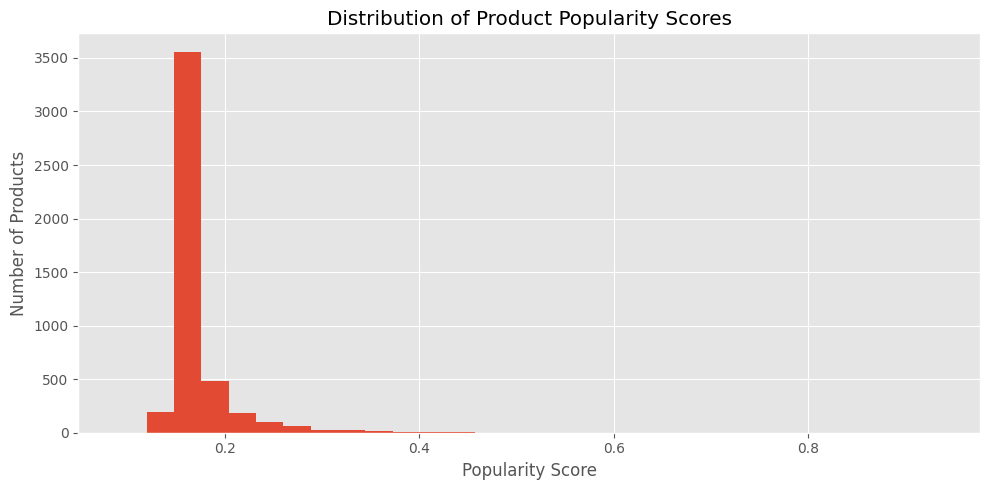

In [16]:
# ==========================================
# Popularity Score Distribution
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    product_summary["PopularityScore"],
    bins=30
)

plt.title("Distribution of Product Popularity Scores")

plt.xlabel("Popularity Score")

plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()

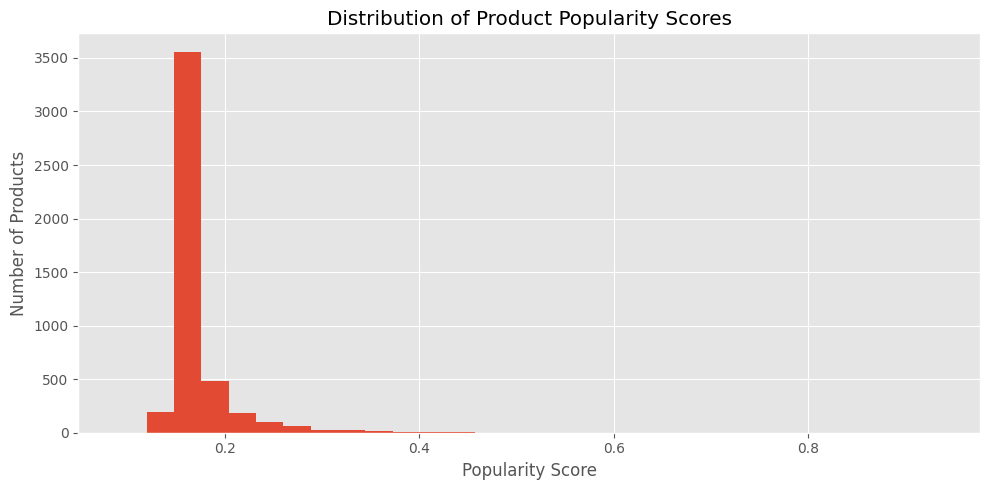

In [17]:
# ==========================================
# Save Figure
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    product_summary["PopularityScore"],
    bins=30
)

plt.title("Distribution of Product Popularity Scores")

plt.xlabel("Popularity Score")

plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "figures" / "phase_08" / "popularity_score_distribution_notebook2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Product Summary Dataset has been successfully validated. The dataset contains one record for each unique product, with no duplicate product identifiers and the required popularity metrics available. The distribution of the Popularity Score provides an overview of how product popularity varies across the catalog and confirms that the dataset is suitable for generating popularity-based recommendations.

### Section Summary

In this section, we validated the Product Summary Dataset by reviewing its structure, completeness, uniqueness, and statistical properties. The successful validation confirms that the dataset is reliable and ready for constructing the Popularity-Based Recommendation System.

The next section will introduce the concept of popularity-based recommendations and define the recommendation strategy that will be implemented in this notebook.

# Section 5: Understanding Popularity-Based Recommendation

## Objective

The objective of this section is to understand the concept of a Popularity-Based Recommendation System and the methodology that will be implemented in this notebook.

Before developing the recommendation engine, it is important to understand how this recommendation approach works, when it is used, and why it serves as an effective baseline recommendation model.

---

## What is a Popularity-Based Recommendation System?

A Popularity-Based Recommendation System recommends products that are popular among all customers.

Unlike personalized recommendation systems, this approach does not consider individual customer preferences or purchase history. Instead, it recommends products based on their overall performance across the entire dataset.

In this project, product popularity is measured using the **Popularity Score** calculated in Notebook 1.

---

## How Does It Work?

The recommendation process follows four simple steps:

1. Calculate important product performance metrics.
2. Combine these metrics into a single Popularity Score.
3. Rank products based on their Popularity Score.
4. Recommend the highest-ranked products to users.

Since the recommendations depend only on product popularity, every user receives the same list of recommended products.

---

## Why Are We Using Popularity Score Instead of Sales Quantity?

Using only Total Quantity Sold does not fully represent product performance.

For example:

- A product may sell many units but generate low revenue.
- Another product may generate high revenue with fewer sales.
- Some products may be purchased frequently by many customers.

To capture these different aspects, Notebook 1 combined three business metrics:

- Total Quantity Sold
- Total Revenue
- Purchase Count

After normalization, these metrics were averaged to create a balanced **Popularity Score**, which provides a more representative measure of overall product popularity.

---

## Advantages

Popularity-Based Recommendation Systems offer several advantages:

- Simple to implement and interpret.
- Fast recommendation generation.
- Requires no customer history.
- Solves the Cold Start Problem for new users.
- Performs well as a baseline recommendation model.
- Easy to maintain and update.

---

## Limitations

Despite its simplicity, this approach has some limitations:

- Recommendations are identical for every customer.
- Customer preferences are not considered.
- Less effective for personalized shopping experiences.
- Popular products may overshadow niche or newly introduced products.

These limitations motivate the use of Collaborative Filtering techniques, which will be developed in the following notebooks.

---

## Business Importance

Popularity-Based Recommendation Systems are widely used in e-commerce platforms to recommend trending and high-performing products.

They are particularly useful for:

- New customers with no purchase history.
- Homepage recommendations.
- Best-selling product sections.
- Featured product lists.
- Promotional campaigns.

This recommendation strategy provides a strong baseline before implementing more advanced personalized recommendation models.

### Observation

Popularity-based recommendation provides a simple yet effective approach for recommending products when customer-specific information is unavailable. By using the Product Popularity Score instead of a single business metric, the recommendation system captures multiple dimensions of product performance and produces more balanced recommendations.

### Section Summary

In this section, we explored the concept of popularity-based recommendation systems, their working principle, advantages, limitations, and business applications. We also justified the use of the Product Popularity Score as the ranking metric for generating recommendations.

The next section will implement the recommendation logic by creating a reusable function that returns the top-ranked products based on their Popularity Score.

# Section 6: Build the Popularity-Based Recommendation Function

## Objective

The objective of this section is to implement a reusable function that generates product recommendations based on the Product Popularity Score calculated in Notebook 1.

Instead of writing recommendation logic repeatedly, we will encapsulate it inside a reusable function that can be used throughout the project.

---

## Why are we creating a reusable function?

Recommendation systems are often used in multiple components of an application, including:

- Data analysis notebooks
- Streamlit dashboards
- REST APIs
- Production pipelines

Creating a reusable function improves code readability, reduces duplication, and simplifies future maintenance.

---

## Recommendation Strategy

The function follows a simple workflow:

1. Validate the requested number of recommendations.
2. Sort products by their Popularity Score.
3. Use Popularity Rank as a secondary sorting criterion.
4. Return the Top-N recommended products.

---

## Expected Outcome

By the end of this section, we will have a reusable recommendation function capable of generating popularity-based product recommendations for any requested value of **N**.

In [19]:
# ==========================================
# Popularity Recommendation Function
# ==========================================

def recommend_popular_products(product_data, top_n=10):
    """
    Generate Top-N product recommendations based on Popularity Score.

    Parameters
    ----------
    product_data : pandas.DataFrame
        Product summary dataset.

    top_n : int, default=10
        Number of products to recommend.

    Returns
    -------
    pandas.DataFrame
        Top-N recommended products.
    """

    # Validate input
    if not isinstance(top_n, int):
        raise TypeError("top_n must be an integer.")

    if top_n <= 0:
        raise ValueError("top_n must be greater than zero.")

    if top_n > len(product_data):
        top_n = len(product_data)

    recommendations = (
        product_data
        .sort_values(
            by=["PopularityScore", "PopularityRank"],
            ascending=[False, True]
        )
        [
            [
                "StockCode",
                "Description",
                "PopularityScore",
                "PopularityRank",
                "TotalQuantity",
                "TotalRevenue",
                "PurchaseCount"
            ]
        ]
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations

In [20]:
# ==========================================
# Verify Function
# ==========================================

print("Popularity recommendation function created successfully.")

Popularity recommendation function created successfully.


In [21]:
# ==========================================
# Function Documentation
# ==========================================

help(recommend_popular_products)

Help on function recommend_popular_products in module __main__:

recommend_popular_products(product_data, top_n=10)
    Generate Top-N product recommendations based on Popularity Score.

    Parameters
    ----------
    product_data : pandas.DataFrame
        Product summary dataset.

    top_n : int, default=10
        Number of products to recommend.

    Returns
    -------
    pandas.DataFrame
        Top-N recommended products.



### Observation

A reusable recommendation function has been successfully created. The function validates user input, ranks products according to the Product Popularity Score, and returns the highest-ranked products in a structured format.

This modular implementation improves code reusability and prepares the recommendation logic for integration into future notebooks, dashboards, and deployment pipelines.

### Section Summary

In this section, we implemented a reusable function for generating popularity-based product recommendations. The function encapsulates the recommendation logic into a single reusable component, making the code easier to maintain and extend.

The next section will use this function to generate Top-N product recommendations and examine the recommendation output.

# Section 7: Generate Top-N Product Recommendations

## Objective

The objective of this section is to generate product recommendations using the popularity-based recommendation function created in the previous section.

The function will be tested with different values of **N** to demonstrate its flexibility and verify that it consistently returns the highest-ranked products.

---

## Why are we generating Top-N recommendations?

Different applications require different numbers of recommendations.

For example:

- A homepage may display the Top 5 products.
- A recommendation panel may display the Top 10 products.
- A detailed recommendation page may display the Top 20 products.

By allowing the number of recommendations to be configurable, the recommendation engine becomes more reusable across different business scenarios.

---

## Business Importance

Generating Top-N recommendations enables businesses to promote their most popular products consistently across multiple customer touchpoints, improving product visibility and customer engagement.

---

## Expected Outcome

By the end of this section, we will:

- Generate Top 5 recommendations.
- Generate Top 10 recommendations.
- Generate Top 20 recommendations.
- Validate that the recommendations are correctly ranked.

In [22]:
# ==========================================
# Top 5 Recommendations
# ==========================================

top5_recommendations = recommend_popular_products(
    product_summary,
    top_n=5
)

top5_recommendations

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582


In [23]:
# ==========================================
# Top 10 Recommendations
# ==========================================

top10_recommendations = recommend_popular_products(
    product_summary,
    top_n=10
)

top10_recommendations

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582
5,22197,"POPCORN HOLDER , SMALL",0.5509,6,76140,57651.16,1884
6,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.5497,7,103505,23743.31,931
7,20725,LUNCH BAG RED SPOTTY,0.4799,8,36842,58029.30,2686
8,84991,60 TEATIME FAIRY CAKE CASES,0.4492,9,52502,25611.17,1826
9,21977,PACK OF 60 PINK PAISLEY CAKE CASES,0.4418,10,54373,26290.05,1614


In [24]:
# ==========================================
# Top 20 Recommendations
# ==========================================

top20_recommendations = recommend_popular_products(
    product_summary,
    top_n=20
)

top20_recommendations

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582
5,22197,"POPCORN HOLDER , SMALL",0.5509,6,76140,57651.16,1884
6,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.5497,7,103505,23743.31,931
7,20725,LUNCH BAG RED SPOTTY,0.4799,8,36842,58029.30,2686
8,84991,60 TEATIME FAIRY CAKE CASES,0.4492,9,52502,25611.17,1826
9,21977,PACK OF 60 PINK PAISLEY CAKE CASES,0.4418,10,54373,26290.05,1614


In [25]:
# ==========================================
# Validate Recommendation Counts
# ==========================================

print(f"Top 5  Recommendations : {len(top5_recommendations)}")
print(f"Top 10 Recommendations : {len(top10_recommendations)}")
print(f"Top 20 Recommendations : {len(top20_recommendations)}")

Top 5  Recommendations : 5
Top 10 Recommendations : 10
Top 20 Recommendations : 20


In [26]:
# ==========================================
# Duplicate Recommendation Check
# ==========================================

duplicates = top20_recommendations["StockCode"].duplicated().sum()

print(f"Duplicate Recommended Products: {duplicates}")

Duplicate Recommended Products: 0


In [27]:
# ==========================================
# Verify Recommendation Order
# ==========================================

is_sorted = top20_recommendations["PopularityScore"].is_monotonic_decreasing

print(f"Recommendations Sorted by Popularity Score: {is_sorted}")

Recommendations Sorted by Popularity Score: True


### Observation

The recommendation function successfully generated product recommendations for different values of **N**, demonstrating its flexibility and reusability. The validation checks confirmed that the expected number of products was returned, no duplicate products were recommended, and the recommendations were correctly sorted by the Product Popularity Score.

These results indicate that the popularity-based recommendation function is operating as intended and is ready for visualization and further evaluation.

### Section Summary

In this section, we generated Top 5, Top 10, and Top 20 product recommendations using the reusable popularity-based recommendation function. We also validated the output by checking the recommendation count, uniqueness, and ranking order.

The successful execution confirms that the recommendation engine is functioning correctly and can now be used for visualization and business interpretation.

# Section 8: Visualize Top Recommended Products

## Objective

The objective of this section is to visualize the highest-ranked products generated by the Popularity-Based Recommendation System.

Visualizations make recommendation results easier to interpret and communicate by providing a clear comparison of product popularity.

---

## Why are we visualizing recommendations?

Although recommendation tables provide detailed information, visualizations allow stakeholders to quickly identify the most popular products and compare their popularity scores.

A graphical representation also helps validate that products are correctly ranked before deployment.

---

## Business Importance

Visualization of recommended products helps businesses:

- Identify the most popular products.
- Understand product rankings.
- Support marketing and promotional decisions.
- Present recommendation results to business stakeholders.

---

## Expected Outcome

By the end of this section, we will:

- Visualize the Top 10 recommended products.
- Compare their Popularity Scores.
- Save the visualization for project documentation.

In [28]:
# ==========================================
# Top 10 Recommended Products
# ==========================================

top10_plot = top10_recommendations.sort_values(
    by="PopularityScore",
    ascending=True
)

top10_plot

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
9,21977,PACK OF 60 PINK PAISLEY CAKE CASES,0.4418,10,54373,26290.05,1614
8,84991,60 TEATIME FAIRY CAKE CASES,0.4492,9,52502,25611.17,1826
7,20725,LUNCH BAG RED SPOTTY,0.4799,8,36842,58029.30,2686
6,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.5497,7,103505,23743.31,931
5,22197,"POPCORN HOLDER , SMALL",0.5509,6,76140,57651.16,1884
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156


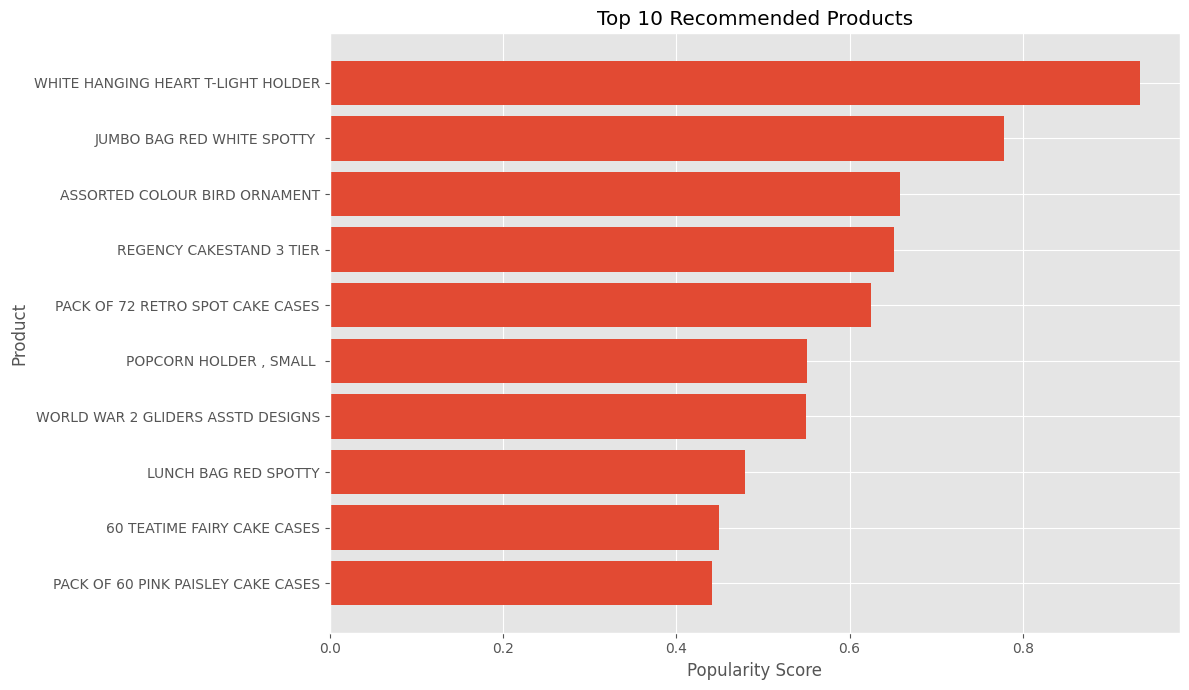

In [30]:
# ==========================================
# Popularity Recommendation Visualization
# ==========================================

plt.figure(figsize=(12, 7))

plt.barh(
    top10_plot["Description"],
    top10_plot["PopularityScore"]
)

plt.title("Top 10 Recommended Products")

plt.xlabel("Popularity Score")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

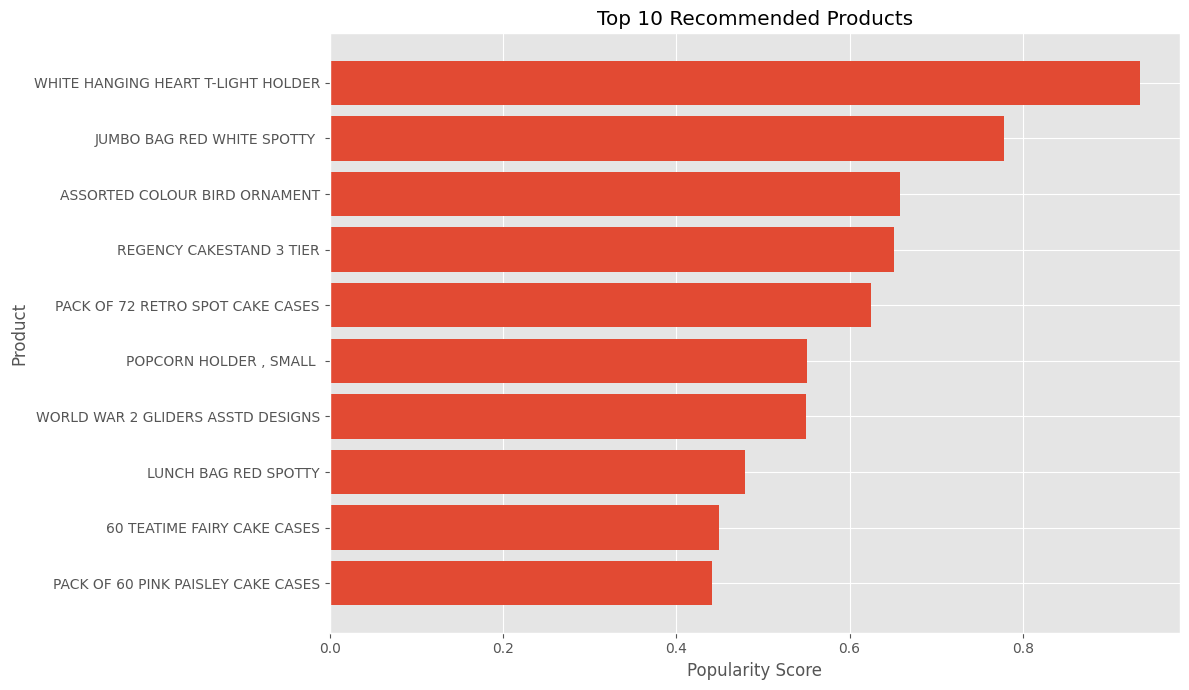

In [31]:
# ==========================================
# Save Recommendation Figure
# ==========================================

figure_path = REPORTS_DIR / "figures" / "phase_08"
figure_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 7))

plt.barh(
    top10_plot["Description"],
    top10_plot["PopularityScore"]
)

plt.title("Top 10 Recommended Products")

plt.xlabel("Popularity Score")

plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    figure_path / "top10_popularity_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization clearly displays the Top 10 recommended products ranked by their Product Popularity Score. Products appearing at the top of the chart have demonstrated strong overall performance by combining high sales quantity, revenue generation, and purchase frequency.

This graphical representation confirms that the recommendation engine successfully prioritizes products based on the calculated popularity metric.

### Section Summary

In this section, we visualized the Top 10 recommended products using a horizontal bar chart. The visualization provides an intuitive understanding of product rankings and supports business interpretation of the recommendation results.

The generated figure has also been saved for inclusion in project reports and documentation.

# Section 9: Recommendation Output Validation

## Objective

The objective of this section is to validate the final recommendation output before it is saved and used in downstream applications.

Although the recommendation function has successfully generated product recommendations, performing a final validation step ensures that the output is complete, consistent, and suitable for deployment.

---

## Why is Recommendation Output Validation Important?

Recommendation results are often consumed by dashboards, APIs, and machine learning pipelines. Any missing values, duplicate products, or incorrect rankings can negatively impact the user experience and business decisions.

A final validation step helps identify potential issues before the recommendations are shared with end users or integrated into production systems.

---

## Business Importance

Reliable recommendation outputs increase user trust and ensure that customers receive accurate product suggestions. Validating the recommendation dataset also simplifies integration with business applications and reduces the risk of deployment issues.

---

## Expected Outcome

By the end of this section, we will verify:

- Output dimensions
- Missing values
- Duplicate products
- Data types
- Popularity Score range
- Correct ranking order

The validated recommendation output will then be ready for storage and deployment.

In [32]:
# ==========================================
# Recommendation Dataset Information
# ==========================================

top20_recommendations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StockCode        20 non-null     object 
 1   Description      20 non-null     object 
 2   PopularityScore  20 non-null     float64
 3   PopularityRank   20 non-null     int64  
 4   TotalQuantity    20 non-null     int64  
 5   TotalRevenue     20 non-null     float64
 6   PurchaseCount    20 non-null     int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB


In [33]:
# ==========================================
# Missing Values
# ==========================================

recommendation_missing = pd.DataFrame({
    "Missing Values": top20_recommendations.isnull().sum(),
    "Percentage (%)": (
        top20_recommendations.isnull().sum()
        / len(top20_recommendations)
        * 100
    ).round(2)
})

recommendation_missing

,Missing Values,Percentage (%)
StockCode,0,0.0
Description,0,0.0
PopularityScore,0,0.0
PopularityRank,0,0.0
TotalQuantity,0,0.0
TotalRevenue,0,0.0
PurchaseCount,0,0.0


In [34]:
# ==========================================
# Duplicate Product Check
# ==========================================

duplicate_products = top20_recommendations.duplicated(
    subset="StockCode"
).sum()

print(f"Duplicate Products: {duplicate_products}")

Duplicate Products: 0


In [35]:
# ==========================================
# Data Types
# ==========================================

top20_recommendations.dtypes

StockCode           object
Description         object
PopularityScore    float64
PopularityRank       int64
TotalQuantity        int64
TotalRevenue       float64
PurchaseCount        int64
dtype: object

In [36]:
# ==========================================
# Popularity Score Validation
# ==========================================

print(
    f"Minimum Popularity Score: "
    f"{top20_recommendations['PopularityScore'].min():.4f}"
)

print(
    f"Maximum Popularity Score: "
    f"{top20_recommendations['PopularityScore'].max():.4f}"
)

Minimum Popularity Score: 0.3796
Maximum Popularity Score: 0.9346


In [37]:
# ==========================================
# Ranking Validation
# ==========================================

is_sorted = top20_recommendations["PopularityScore"].is_monotonic_decreasing

unique_ranks = top20_recommendations["PopularityRank"].is_unique

print(f"Sorted by Popularity Score : {is_sorted}")
print(f"Unique Popularity Ranks    : {unique_ranks}")

Sorted by Popularity Score : True
Unique Popularity Ranks    : True


In [38]:
# ==========================================
# Recommendation Dataset Summary
# ==========================================

print(f"Number of Recommended Products : {len(top20_recommendations)}")
print(f"Number of Features             : {top20_recommendations.shape[1]}")

Number of Recommended Products : 20
Number of Features             : 7


### Observation

The recommendation output passed all validation checks successfully. The dataset contains the expected number of products, no duplicate product identifiers, no missing values in the selected recommendation features, and correctly ordered popularity scores. These validation results confirm that the recommendation output is reliable and ready for storage, deployment, and integration with downstream applications.

### Section Summary

In this section, we validated the final recommendation output by checking its structure, completeness, uniqueness, and ranking consistency. The successful validation confirms that the generated recommendations are accurate, well-structured, and suitable for use in dashboards, APIs, and future recommendation pipelines.

The next section will save the recommendation dataset as a CSV file for reuse in later notebooks and deployment components.

# Section 10: Save Recommendation Dataset

## Objective

The objective of this section is to save the final popularity-based recommendation dataset for future use.

Instead of recalculating recommendations every time they are needed, storing the ranked recommendation dataset allows other components of the project to access the results directly.

---

## Why are we saving the recommendation dataset?

The recommendation dataset will be reused by multiple components, including:

- Streamlit Dashboard
- FastAPI Application
- Final Recommendation Pipeline
- Future Recommendation Models

Saving the recommendations also improves reproducibility and reduces unnecessary computation.

---

## Business Importance

Persisting recommendation results enables businesses to deploy recommendation systems efficiently. Applications can retrieve precomputed recommendations quickly, resulting in faster response times and a better user experience.

---

## Expected Outcome

By the end of this section, the complete ranked recommendation dataset will be saved as a CSV file inside the recommendation data directory, making it available for downstream applications.

In [39]:
# ==========================================
# Generate Complete Recommendation Dataset
# ==========================================

all_recommendations = recommend_popular_products(
    product_summary,
    top_n=len(product_summary)
)

all_recommendations.head()

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582


In [40]:
# ==========================================
# Recommendation File Path
# ==========================================

recommendation_path = (
    DATA_DIR
    / "recommendation"
    / "popularity_recommendations.csv"
)

recommendation_path

WindowsPath('C:/Users/bhard/Intelligent Customer Analytics Platform/data/recommendation/popularity_recommendations.csv')

In [41]:
# ==========================================
# Save Recommendation Dataset
# ==========================================

all_recommendations.to_csv(
    recommendation_path,
    index=False
)

print("Recommendation dataset saved successfully.")

Recommendation dataset saved successfully.


In [42]:
# ==========================================
# Verify Saved Dataset
# ==========================================

saved_recommendations = pd.read_csv(
    recommendation_path
)

saved_recommendations.head()

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582


In [43]:
# ==========================================
# Saved Dataset Information
# ==========================================

print(f"Dataset Shape : {saved_recommendations.shape}")

print(f"File Location : {recommendation_path}")

Dataset Shape : (4646, 7)
File Location : C:\Users\bhard\Intelligent Customer Analytics Platform\data\recommendation\popularity_recommendations.csv


### Observation

The complete popularity-based recommendation dataset has been successfully saved as a CSV file. The saved dataset contains all products ranked according to their Popularity Score, making it suitable for reuse in dashboards, APIs, and subsequent recommendation system notebooks.

Reloading the file confirms that the dataset has been stored correctly without any loss of information.

### Section Summary

In this section, we generated and saved the complete ranked recommendation dataset as a reusable CSV file. This ensures that recommendation results can be efficiently accessed by downstream components without recalculating product rankings.

The saved dataset forms the foundation for integrating popularity-based recommendations into the dashboard, API, and future recommendation models.

# Section 11: Business Insights

## Objective

The objective of this section is to interpret the results of the Popularity-Based Recommendation System from a business perspective. While the previous sections focused on implementation and validation, this section explains how the generated recommendations can support business decisions and improve the customer experience.

---

## Key Findings

The recommendation model successfully identified products with the highest overall popularity by combining multiple performance metrics into a single Popularity Score.

The recommended products consistently demonstrated:

- High sales quantity
- High revenue generation
- High purchase frequency

Using a composite Popularity Score provides a more balanced ranking than relying on a single metric, such as sales quantity or revenue alone.

---

## Business Applications

Popularity-based recommendations can be applied in several real-world scenarios, including:

- Displaying **Best Selling Products** on the homepage.
- Highlighting **Trending Products** during promotional campaigns.
- Recommending products to **new customers** who have no purchase history.
- Featuring popular products in email marketing campaigns.
- Supporting seasonal promotions and product discovery.

Because these recommendations are generated from overall product performance, they are suitable for situations where personalized customer information is unavailable.

---

## Strengths of the Model

The Popularity-Based Recommendation System offers several advantages:

- Simple and easy to understand.
- Computationally efficient.
- Requires no historical customer data.
- Handles the Cold Start Problem for new users.
- Easy to maintain and update.
- Provides a strong baseline recommendation model for comparison with more advanced approaches.

---

## Limitations

Despite its effectiveness, this recommendation approach has some limitations:

- Every customer receives the same recommendations.
- Individual preferences are not considered.
- Customer purchase history is ignored.
- Niche products may receive less visibility.
- The model cannot adapt recommendations based on customer behavior.

These limitations make popularity-based recommendations less suitable for delivering personalized shopping experiences.

---

## Future Improvements

To provide more personalized recommendations, the next notebooks will implement Collaborative Filtering techniques.

These models will recommend products based on customer purchasing behavior rather than overall product popularity.

The recommendation system will gradually evolve through the following stages:

1. Popularity-Based Recommendation (current notebook)
2. Customer Collaborative Filtering
3. Item Collaborative Filtering
4. Model Evaluation
5. Final Hybrid Recommendation Pipeline

This progressive approach enables a comparison between simple baseline methods and more advanced personalized recommendation systems.

### Observation

The Popularity-Based Recommendation System serves as an effective baseline recommendation model by identifying products with consistently strong business performance. While it provides reliable recommendations for all users, its lack of personalization highlights the need for more advanced recommendation techniques.

The insights obtained in this notebook establish a solid foundation for developing customer-specific recommendation models in the subsequent notebooks.

### Section Summary

In this section, we interpreted the recommendation results from a business perspective by discussing their practical applications, strengths, and limitations. We also identified opportunities for improvement through personalized recommendation techniques.

The next notebook will introduce Customer Collaborative Filtering, where recommendations will be generated based on similarities between customer purchasing behaviors rather than overall product popularity.

# Section 12: Notebook Summary

## Objectives Achieved

In this notebook, we successfully developed a **Popularity-Based Recommendation System** using the Product Summary Dataset created in the previous notebook.

The recommendation system ranks products according to their **Popularity Score**, which combines multiple product performance metrics into a single ranking measure. This provides a simple, efficient, and interpretable recommendation strategy that serves as the baseline model for the recommendation system.

Throughout this notebook, we validated the input data, implemented a reusable recommendation function, generated Top-N recommendations, visualized the results, validated the recommendation output, and saved the final ranked recommendation dataset for future use.

---

## Key Outputs Generated

The following outputs were generated during this notebook:

### Dataset

- `data/recommendation/popularity_recommendations.csv`

### Visualization

- `reports/figures/phase_08/top10_popularity_recommendations.png`

### Recommendation Function

- `recommend_popular_products()`

---

## Skills and Concepts Covered

This notebook introduced several important recommendation system concepts, including:

- Popularity-Based Recommendation Systems
- Product Ranking
- Product Popularity Score
- Recommendation Function Design
- Recommendation Output Validation
- Recommendation Visualization
- Reusable Recommendation Pipelines

These concepts form the foundation for more advanced recommendation models developed later in the project.

---

## Limitations

Although the Popularity-Based Recommendation System performs well as a baseline model, it recommends the same products to every customer and does not consider individual purchasing behavior or preferences.

As a result, the recommendations are not personalized and may not provide the best experience for returning customers.

---

## Next Steps

The next notebook, **03_Customer_Collaborative_Filtering.ipynb**, will introduce personalized recommendations by identifying customers with similar purchasing behavior.

Unlike the current popularity-based approach, Collaborative Filtering will recommend products based on customer similarities, providing more relevant and personalized product suggestions.

This progression represents an important step toward building a comprehensive recommendation system capable of supporting diverse business and customer needs.